# Aim
The aim of this notebook is to prototype an analysis pipeline for Thomas's data. Neurons, cilia all that we can wish for.

## Overview
3D Immunos for neurite, cilia, nuclei, (additionally basal body) - 


# 1. Helper functions

In [1]:
from imaris_ims_file_reader.ims import ims
import numpy as np
import os
import re
from tqdm import tqdm
import pyclesperanto_prototype as cle
import matplotlib.pyplot as plt
import napari
from skimage.morphology import skeletonize, medial_axis
from skan.csr import skeleton_to_csgraph, Skeleton, summarize
from skan import draw
from skimage.feature import shape_index
from skimage.measure import regionprops
from scipy.spatial import cKDTree
import pandas as pd
from stackview import insight
from scipy.ndimage import distance_transform_edt

In [2]:
from utils import reader
ims_path = "H:/tlobri/2. Experiments, Differentiations and Adaptations/4. Cilia on Neurites/EXP_E6_250807/250819 - BC43 IF WTSII ROIs/EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims"

a, meta = reader.load_image(ims_path)


Opening .ims file: \\idnas37.d.uzh.ch\G_MLS_RB_UHome$\tlobri\2. Experiments, Differentiations and Adaptations\4. Cilia on Neurites\EXP_E6_250807\250819 - BC43 IF WTSII ROIs\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims
Opening readonly file: \\idnas37.d.uzh.ch\G_MLS_RB_UHome$\tlobri\2. Experiments, Differentiations and Adaptations\4. Cilia on Neurites\EXP_E6_250807\250819 - BC43 IF WTSII ROIs\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).ims 

Shape (T, C, Z, Y, X): (1, 4, 23, 2040, 2040)
Number of timepoints: 1
Number of channels: 4
Image dimensions (Z, Y, X): (23, 2040, 2040)
Z Resolution: 0.383
XY Resolution: (0.152, 0.152)


If for some reason the meta data is not found in the .ims, in many Imaris exports there is a **metadata text file** next to the `.ims` file,
for example:
- `METH-PLTurbID-2h-pfa_2026-02-12_12.33.21.ims`
- `METH-PLTurbID-2h-pfa_2026-02-12_12.33.21_metadata.txt`

This step:
- Looks for a matching `*_metadata.txt` file next to your `.ims`
- Reads voxel sizes (pixel size in µm, Z-step in µm) and channel information
- Stores these values so later steps can report **real volumes in µm³** instead of just voxel counts.

If no metadata file is found, the notebook will keep using default voxel sizes (1.0 µm).

In [3]:
meta_text = reader.load_ims_metadata(ims_path)

Using metadata file:
 H:/tlobri/2. Experiments, Differentiations and Adaptations/4. Cilia on Neurites/EXP_E6_250807/250819 - BC43 IF WTSII ROIs\EXP_E6_d40_WTSII_DAPI_PCN488_TUJ1568_ARL13B647_40x_2025-08-19_(9).txt

Pixel size XY: 0.1523 µm
Z resolution (Reference Z Resolution): 0.1000 µm
Wavelengths (nm): [700.0, 600.0, 529.0, 445.0]

Stored voxel sizes: Z=0.1000 µm, Y=0.1523 µm, X=0.1523 µm


watch out as sometimes the format is inconsistent and resolutions are not found in the txt file they will default to 1

Select GPU for clesperanto library

In [4]:
print(cle.available_device_names(dev_type="gpu"))
cle.select_device('NVIDIA GeForce RTX 4090')  # optional but good practice
print(cle.get_device())

['NVIDIA GeForce RTX 4090', 'gfx1036']
<NVIDIA GeForce RTX 4090 on Platform: NVIDIA CUDA (1 refs)>


In [5]:
# Simple default colormaps for a few channels
DEFAULT_COLORMAPS = ["yellow", "green", "red", "blue", "magenta", "cyan"]
CHANNEL_NAMES = ["cilia", "neurites", "basal_bodies", "nuclei"]
scale = (meta['voxel_size'])
viewer = napari.Viewer(ndisplay=3)
viewer.dims.axis_labels = ['Z', 'Y', 'X']
def set_layer_scale(event):
    layer = event.value
    if hasattr(layer, 'scale'):
        layer.scale = scale

# Connect the function to layer insertion events
viewer.layers.events.inserted.connect(set_layer_scale)

T, C, Z, Y, X = a.shape

for c in range(C):
    #volume = (volumes[c] - volumes[c].min()) / (volumes[c].max() - volumes[c].min())  # min - max normalization 
    volume = a[0,c]
    cmap = DEFAULT_COLORMAPS[c % len(DEFAULT_COLORMAPS)]
    viewer.add_image(volume, name=f"Channel {CHANNEL_NAMES[c]}", colormap=cmap, blending="additive", scale=scale, units='um')

print("Napari viewer opened. Use the sliders to explore. Close the window to continue.")
napari.run()


Napari viewer opened. Use the sliders to explore. Close the window to continue.


# 3. Processing
still quick and dirty (need to decide how to normalize stuff)

# 3.1 process cilia 


we can train a classifier for the cilia as well as it is a bit more robust

In [6]:
from apoc import ObjectSegmenter

def cilia_process_3d_ml(volume,classifier_path="c:/Users/qfavey/Documents/Code-Thomas-Test/LimonCELLo/cilia-segmenter.cl",min_size=20):
    segmenter = ObjectSegmenter(opencl_filename=classifier_path)
    result = segmenter.predict(image=volume)
    filtered_result = cle.exclude_small_labels(cle.push(result), maximum_size=min_size)
    return filtered_result

In [7]:
cilia_labels = cilia_process_3d_ml(a[0,0])

In [8]:
viewer.add_labels(cilia_labels, name=f"cilia_labels_ml", blending="additive" )

<Labels layer 'cilia_labels_ml' at 0x22c5a4664d0>

# 3.2 Process Nuclei
The challenge here is that some of the nuclei come out but do not correspond to any neurites (difference in staining efficacy I guess) we want to exclude them from the analysis so that they do not get assigned any cilia. Quick and dirty way again voronoi otsu



In [9]:
def nuclei_process_3d(
    volume,
    tophat_radius=(2.0, 2.0, 2.0),
    dilation_radius=(2.0, 2.0, 2.0),
    min_size=50,
    spot_sigma = 5, 
    outline_sigma = 1
):
    """
    3D cilia segmentation pipeline on GPU.

    Parameters
    ----------
    volume : np.ndarray
        3D array (Z, Y, X)
    tophat_radius : tuple
        (rx, ry, rz) for 3D top-hat sphere
    dilation_radius : tuple
        (rx, ry, rz) for 3D label dilation
    min_size : int
        Minimum voxel size to keep objects
    spot_sigma: int
        How close detected cells can be
    outline_sigma: int
        How precise the segmented objects are outlined

    Returns
    -------
    result : np.ndarray
        3D labeled volume
    """

    # Push to GPU
    volume_gpu = cle.push(volume)

    # 3D top-hat (sphere)
    th_gpu = cle.top_hat_sphere(
        volume_gpu,
        radius_x=tophat_radius[2],
        radius_y=tophat_radius[2],
        radius_z=tophat_radius[2],
    )

    # 3D Otsu threshold
    labels_gpu = cle.voronoi_otsu_labeling(th_gpu,spot_sigma=spot_sigma, outline_sigma=outline_sigma)

    # Pull back to CPU
    result = cle.pull(labels_gpu)

    return result

run this:

In [10]:
nuclei_spot_sigma = 15
tophat_radius = 12
nuclei_labels_otsu = nuclei_process_3d(a[0,3],tophat_radius=(tophat_radius,tophat_radius,tophat_radius),spot_sigma=nuclei_spot_sigma,outline_sigma=3)
viewer.add_labels(nuclei_labels_otsu, name=f"nuclei_labels_otsu spot_sigma={nuclei_spot_sigma}", blending="additive", scale=scale, units='um' )

<Labels layer 'nuclei_labels_otsu spot_sigma=15' at 0x22c5b9dc070>

We want to get the distance transform of the nuclei channel. Every voxel contains the distance to the nearest nucleus

In [38]:
distance_map = distance_transform_edt(~(nuclei_labels_otsu>0),sampling=meta['voxel_size'])

# 3.3 Process neurites
The idea is to binarize with otsu or ML, use the binary mask to filter out the nuclei that are not in contact. Convert the skeleton to graph, get graph statistics (such as scholl analysis), assign cilia to closest branches and get statistics on the type of the assigned branches, also get closest nuclei to cilia. Hard to tell which cell they belong to in this picture. Additionally, semi automated soma labelling could help with this. And we would not need the dapi signal 

In [12]:
def neurites_process_gpu(neurites, nuclei_labels, min_size=50, spot_sigma=10,outline_sigma=1):

    # ---- Push to GPU ----
    neurites_gpu = cle.push(neurites)
    nuclei_gpu = cle.push(nuclei_labels)

    # ---- Tubular enhancement (DoG instead of Frangi) ----
    # blurred_small = cle.gaussian_blur(neurites_gpu, 1, 1, 0)
    # blurred_large = cle.gaussian_blur(neurites_gpu, 3, 3, 0)
    # enhanced_gpu = cle.subtract_images(blurred_small, blurred_large)

    # ---- Threshold (GPU Otsu) ----
    neurites_label =  cle.exclude_small_labels(cle.voronoi_otsu_labeling(neurites_gpu, spot_sigma=spot_sigma, outline_sigma=outline_sigma),maximum_size=min_size)


    # ---- Skeletonize (CPU fallback) ----
    binary = cle.pull(neurites_label)

    skeleton = skeletonize(binary)
    #skel_med, dist = medial_axis(binary, return_distance=True)

    # ---- GPU Voronoi labeling instead of EDT ----
    # This assigns each pixel to nearest label directly on GPU


    return skeleton, neurites_label

In [13]:
spot_sigma = 5
binary_skeleton, neurites_label = neurites_process_gpu(a[0,1],nuclei_labels_otsu,spot_sigma=spot_sigma)
viewer.add_labels(neurites_label,name=f'neurites label spot_sigma={spot_sigma}', scale=scale, units='um')
viewer.add_image(binary_skeleton,name=f"skeleton spot_sigma={spot_sigma}",colormap="inferno", scale=scale, units='um')

<Image layer 'skeleton spot_sigma=5' at 0x22c13010310>

Merge nuclei and neurites to one label for further classification into soma and dentrites/axon types

In [14]:
def merge_nuclei_neurites(labels_nuclei,labels_neurites,spot_sigma=10,outline_sigma=1):
    # binary or
    image2_bup = cle.binary_or(labels_nuclei, labels_neurites)
    image3_volp = cle.voronoi_otsu_labeling(image2_bup, None, spot_sigma, outline_sigma)
    return image3_volp

In [15]:
nuclei_neurites_merge = merge_nuclei_neurites(nuclei_labels_otsu,neurites_label)
viewer.add_labels(nuclei_neurites_merge, name=f'nuclei merged with neurites')

<Labels layer 'nuclei merged with neurites' at 0x22c181794e0>

## Distance transform shite

In [ ]:
#dt_neurites = distance_map * np.array(neurites_label)
distance_map_neurites = distance_transform_edt(np.array(neurites_label)>0,sampling=meta['voxel_size']) # how thick are the neurites
viewer.add_image(distance_map_neurites,name="dt_neurites", colormap='viridis',)

C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\3799611706.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  distance_map_neurites = distance_transform_edt(np.array(neurites_label)>0) # how thick are the neurites


<Image layer 'dt_neurites' at 0x22c15b850c0>

In [17]:
# Compute raw ratio
map_ratio = distance_map_neurites / distance_map

# Replace infinities (div by zero) with NaN
map_ratio[np.isinf(map_ratio)] = np.nan

# Log ratio, safely ignoring non-positive values
log_map_ratio = np.full_like(map_ratio, np.nan, dtype=np.float64)
positive_mask = map_ratio > 0
log_map_ratio[positive_mask] = np.log(map_ratio[positive_mask])

# Normalize (z-score)
norm_map_ratio = (map_ratio - np.mean(map_ratio)) / np.std(map_ratio)
norm_log_map_ratio = (log_map_ratio - np.mean(log_map_ratio)) / np.std(log_map_ratio)

viewer.add_image(log_map_ratio,name="thickness/nuclei_dist ratio", colormap='viridis',)

C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\3639701481.py:2: RuntimeWarning: divide by zero encountered in divide
  map_ratio = distance_map_neurites / distance_map
C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\3639701481.py:2: RuntimeWarning: invalid value encountered in divide
  map_ratio = distance_map_neurites / distance_map


<Image layer 'thickness/nuclei_dist ratio' at 0x22c6a565990>

C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\2027306674.py:5: RuntimeWarning: divide by zero encountered in divide
  map_ratio = distance_map / distance_map_neurites
C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\2027306674.py:5: RuntimeWarning: invalid value encountered in divide
  map_ratio = distance_map / distance_map_neurites


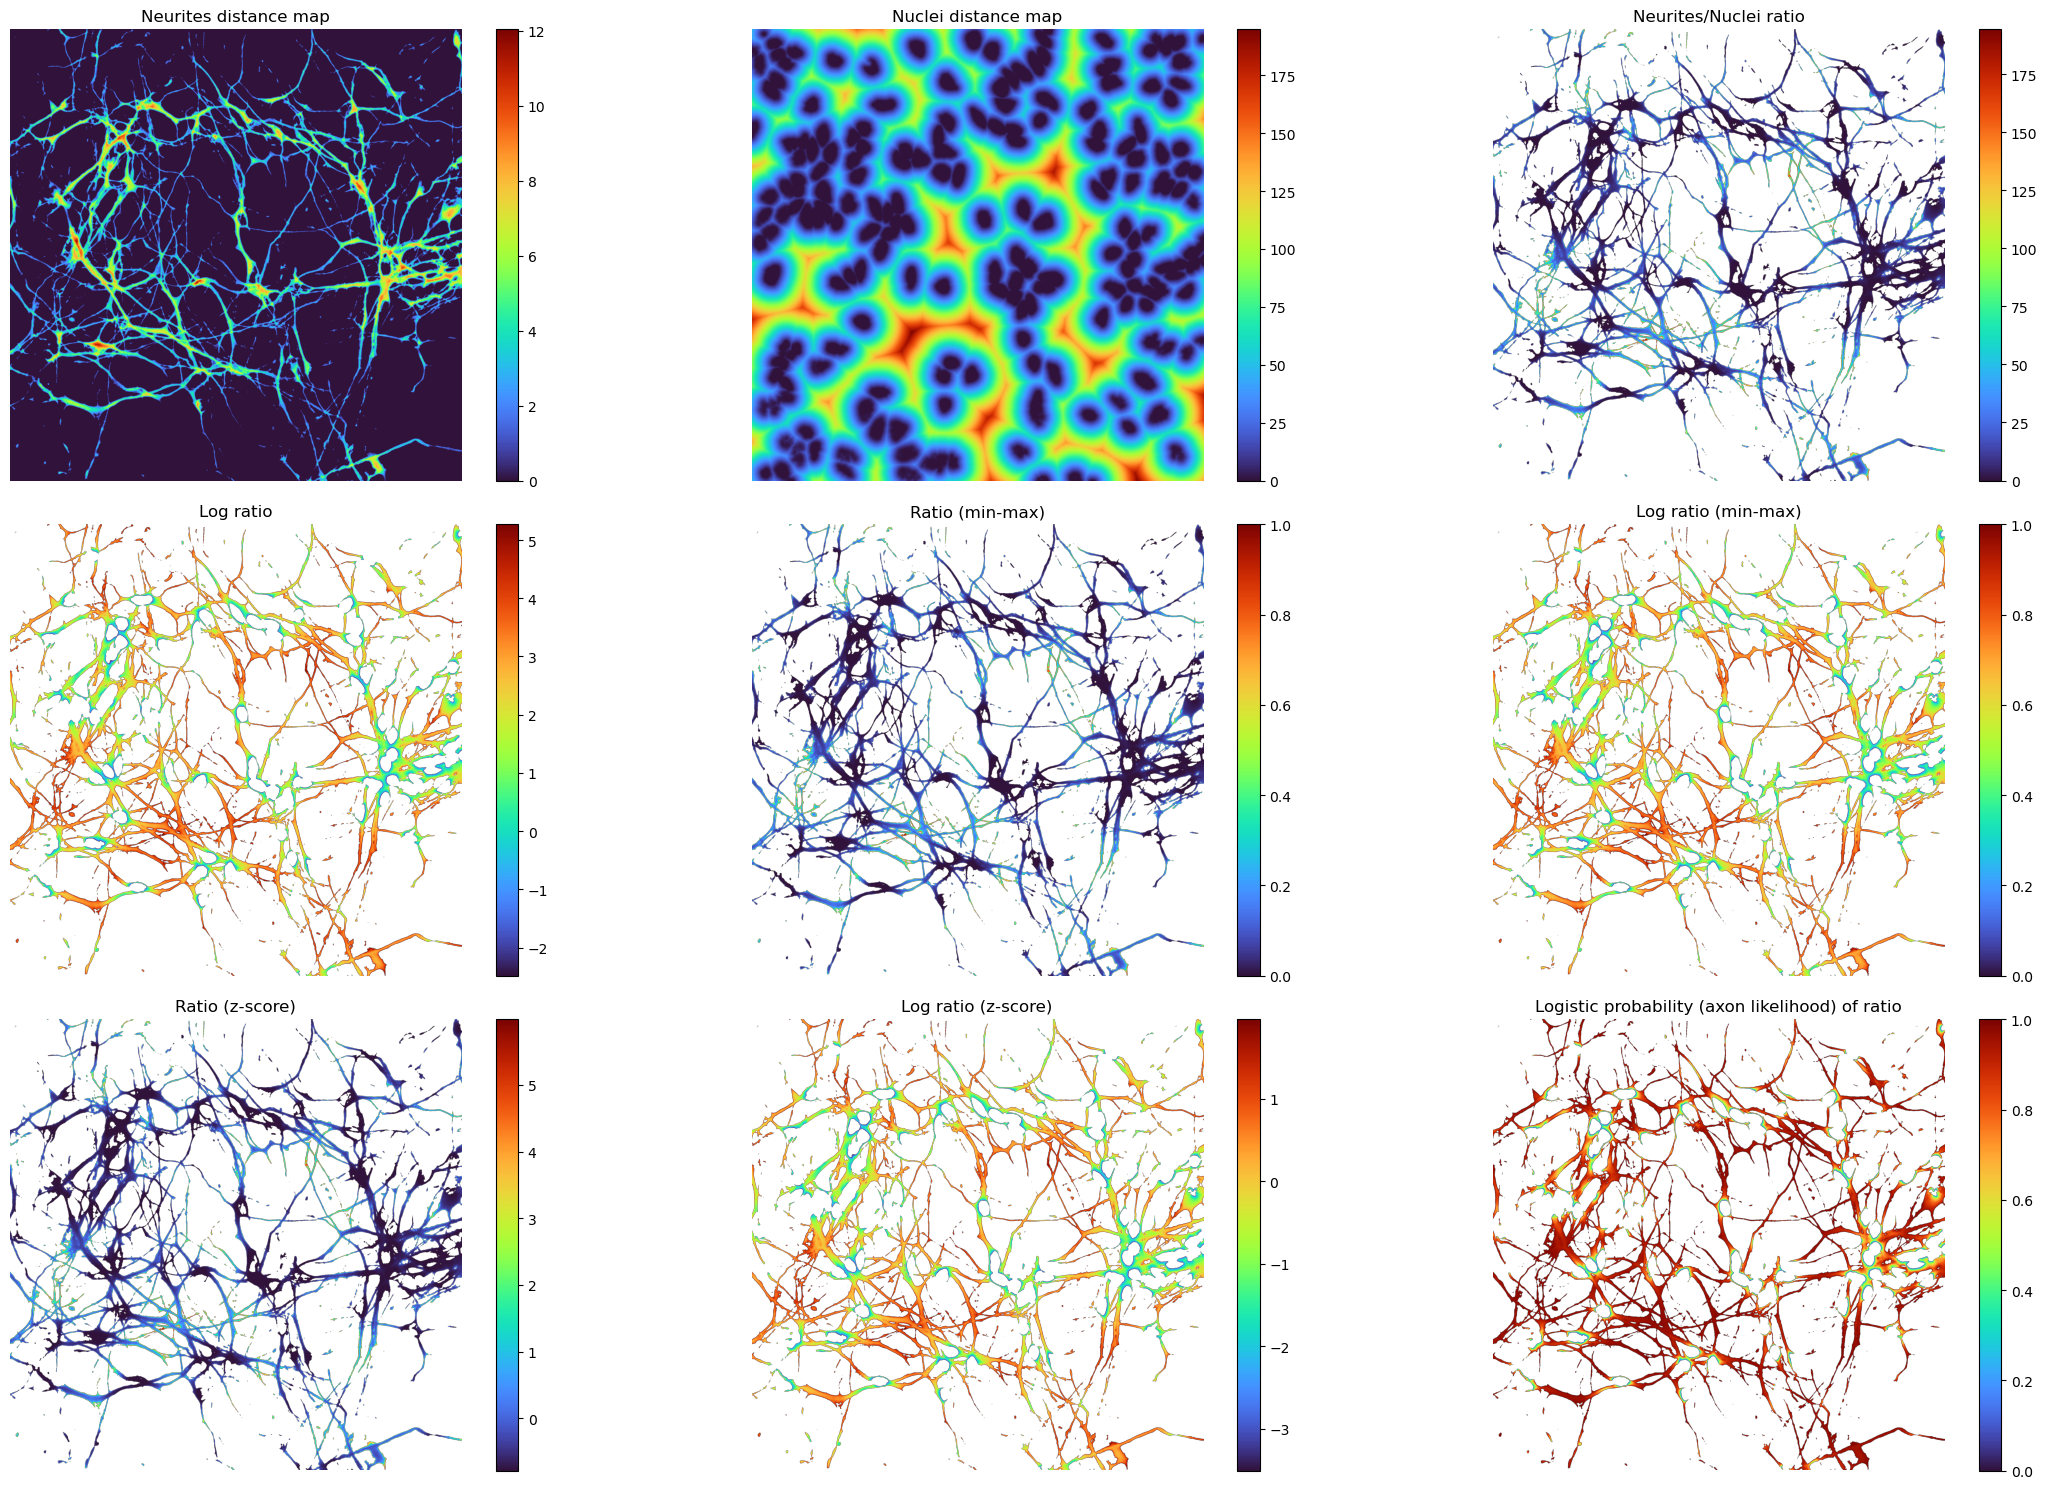

In [18]:

import numpy as np
import matplotlib.pyplot as plt

# --- Compute raw ratio safely ---
map_ratio = distance_map / distance_map_neurites

# Mask invalid values
map_ratio_clean = map_ratio.copy()
map_ratio_clean[~np.isfinite(map_ratio_clean)] = np.nan  # NaN for inf or -inf

# --- Log ratio safely ---
log_map_ratio = np.full_like(map_ratio_clean, np.nan)
positive_mask = map_ratio_clean > 0
log_map_ratio[positive_mask] = np.log(map_ratio_clean[positive_mask])

# --- Normalizations (robust to NaNs) ---
# Min-max
map_ratio_minmax = (map_ratio_clean - np.nanmin(map_ratio_clean)) / (np.nanmax(map_ratio_clean) - np.nanmin(map_ratio_clean))
log_map_ratio_minmax = (log_map_ratio - np.nanmin(log_map_ratio)) / (np.nanmax(log_map_ratio) - np.nanmin(log_map_ratio))

# Z-score
map_ratio_z = (map_ratio_clean - np.nanmean(map_ratio_clean)) / np.nanstd(map_ratio_clean)
log_map_ratio_z = (log_map_ratio - np.nanmean(log_map_ratio)) / np.nanstd(log_map_ratio)

# Logistic probability from log ratio
prob_neurite = np.full_like(map_ratio, np.nan)
prob_mask = np.isfinite(map_ratio)
prob_neurite[prob_mask] = 1 / (1 + np.exp(-log_map_ratio[prob_mask]))

# --- Choose middle slice for visualization ---
slice_idx = map_ratio.shape[0] // 2

# --- Prepare figure ---
fig, axes = plt.subplots(3, 3, figsize=(24, 15))
axes = axes.ravel()

# Original maps
im0 = axes[0].imshow(distance_map_neurites[slice_idx], cmap='turbo')
axes[0].set_title('Neurites distance map')
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(distance_map[slice_idx], cmap='turbo')
axes[1].set_title('Nuclei distance map')
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

im2 = axes[2].imshow(map_ratio_clean[slice_idx], cmap='turbo')
axes[2].set_title('Neurites/Nuclei ratio')
plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

im3 = axes[3].imshow(log_map_ratio[slice_idx], cmap='turbo')
axes[3].set_title('Log ratio')
plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

# Normalized maps
im4 = axes[4].imshow(map_ratio_minmax[slice_idx], cmap='turbo', vmin=0, vmax=1)
axes[4].set_title('Ratio (min-max)')
plt.colorbar(im4, ax=axes[4], fraction=0.046, pad=0.04)

im5 = axes[5].imshow(log_map_ratio_minmax[slice_idx], cmap='turbo', vmin=0, vmax=1)
axes[5].set_title('Log ratio (min-max)')
plt.colorbar(im5, ax=axes[5], fraction=0.046, pad=0.04)

im6 = axes[6].imshow(map_ratio_z[slice_idx], cmap='turbo')
axes[6].set_title('Ratio (z-score)')
plt.colorbar(im6, ax=axes[6], fraction=0.046, pad=0.04)

im7 = axes[7].imshow(log_map_ratio_z[slice_idx], cmap='turbo')
axes[7].set_title('Log ratio (z-score)')
plt.colorbar(im7, ax=axes[7], fraction=0.046, pad=0.04)

# Logistic probability map
im8 = axes[8].imshow(prob_neurite[slice_idx], cmap='turbo', vmin=0, vmax=1)
axes[8].set_title('Logistic probability (axon likelihood) of ratio')
plt.colorbar(im8, ax=axes[8], fraction=0.046, pad=0.04)

# Remove axes ticks
for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [19]:
viewer.add_image(log_map_ratio_z,name="thickness/nuclei_dist ratio", colormap='turbo',)

<Image layer 'thickness/nuclei_dist ratio [1]' at 0x22c131a3b80>

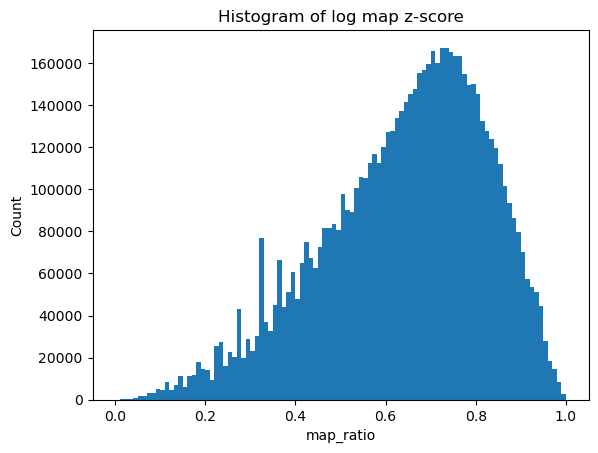

In [20]:
plt.hist(log_map_ratio_minmax.ravel(), bins=100)
plt.xlabel("map_ratio")
plt.ylabel("Count")
plt.title(f"Histogram of log map z-score")
plt.show()

# 4. Analysis


In [21]:
print(np.max(neurites_label))

1669.0


In [22]:
import numpy as np
from scipy.ndimage import distance_transform_edt, center_of_mass



# Distance transform: distance from each voxel to nearest neurite voxel


In [ ]:
import numpy as np
from scipy.ndimage import distance_transform_edt, center_of_mass
import matplotlib.pyplot as plt

# -------------------------
# INPUTS
# -------------------------
# cilia_labels : 3D label image (0 background, >0 individual cilia)
# neurite_mask : 3D binary neurite segmentation
# map_probability : 3D map giving probability voxel belongs to axon

# -------------------------
# 1. Compute nearest neurite for every voxel
# -------------------------

dist_to_neurite, nearest_idx= distance_transform_edt(~(np.array(neurites_label)>0), return_indices=True,sampling=meta['voxel_size'])


# -------------------------
# 2. Get cilia centroids
# -------------------------
cilia_ids = np.unique(cilia_labels)
cilia_ids = cilia_ids[cilia_ids != 0]

centroids = center_of_mass(cilia_labels > 0, labels=cilia_labels, index=cilia_ids)

# -------------------------
# 3. Map each centroid to nearest neurite voxel
# -------------------------
cilia_scores = {}



C:\Users\qfavey\AppData\Local\Temp\ipykernel_151944\613045929.py:16: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  dist_to_neurite, nearest_idx= distance_transform_edt(~(np.array(neurites_label)>0), return_indices=True)


In [24]:
for cid, c in zip(cilia_ids, centroids):

    z, y, x = np.round(c).astype(int)

    z = np.clip(z, 0, cilia_labels.shape[0]-1)
    y = np.clip(y, 0, cilia_labels.shape[1]-1)
    x = np.clip(x, 0, cilia_labels.shape[2]-1)

    # nearest neurite voxel
    nz, ny, nx = nearest_idx[:, z, y, x]

    # probability at that neurite location
    p = map_ratio_z[nz, ny, nx]

    cilia_scores[cid] = p
   
print(cilia_scores)

{np.uint32(1): np.float64(-0.11295298868072051), np.uint32(2): np.float64(0.25398765202387563), np.uint32(3): np.float64(0.242809382873558), np.uint32(4): np.float64(0.878126525174201), np.uint32(5): np.float64(0.18686009222874786), np.uint32(6): np.float64(0.878126525174201), np.uint32(7): np.float64(0.18686009222874786), np.uint32(8): np.float64(0.18686009222874786), np.uint32(9): np.float64(2.498319305159283), np.uint32(10): np.float64(0.04067566028918278), np.uint32(11): np.float64(-0.46839740717294726), np.uint32(12): np.float64(-0.30310291353499347), np.uint32(13): np.float64(-0.27841506090218915), np.uint32(14): np.float64(-0.5588089360037352), np.uint32(15): np.float64(-0.6863907354027555), np.uint32(16): np.float64(-0.2334618630289589), np.uint32(17): np.float64(-0.6138626467952992), np.uint32(18): np.float64(-0.21927528916306174), np.uint32(19): np.float64(-0.2595044055114171), np.uint32(20): np.float64(-0.679242852036128), np.uint32(21): np.float64(-0.45981117352410295), np.

In [27]:
# -------------------------
# 4. Create cilia probability map
# -------------------------
cilia_prob_map = np.zeros_like(cilia_labels, dtype=float)

# Create lookup table
lut = np.zeros(int(cilia_labels.max() + 1))

for cid, p in cilia_scores.items():
    lut[cid] = p

# Map labels to probabilities in one pass
cilia_prob_map = lut[cilia_labels]

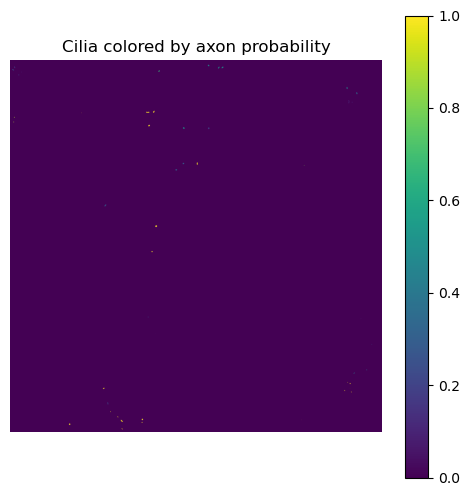

In [28]:



# -------------------------
# 5. Visualize
# -------------------------
slice_idx = cilia_labels.shape[0] // 2

fig, ax = plt.subplots(1,1, figsize=(6,6))

im = ax.imshow(cilia_prob_map[slice_idx], cmap="viridis", vmin=0, vmax=1)
ax.set_title("Cilia colored by axon probability")
ax.axis("off")

plt.colorbar(im, ax=ax)
plt.show()

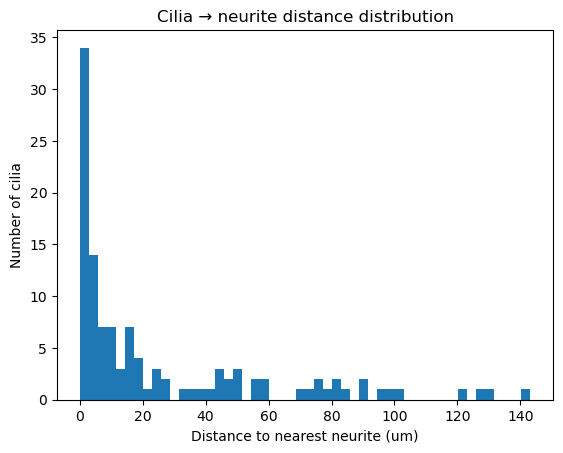

In [43]:
distances = []

for centroid in centroids:

    z, y, x = np.round(centroid).astype(int)
    d = dist_to_neurite[z, y, x]
    distances.append(d)

plt.hist(distances, bins=50)
plt.xlabel("Distance to nearest neurite (um)")
plt.ylabel("Number of cilia")
plt.title("Cilia → neurite distance distribution")
plt.show()

In [40]:
max_distance_um = 2.0

filtered_cilia_ids = []
filtered_centroids = []

for cid, centroid in zip(cilia_ids, centroids):

    z, y, x = np.round(centroid).astype(int)

    z = np.clip(z, 0, dist_to_neurite.shape[0]-1)
    y = np.clip(y, 0, dist_to_neurite.shape[1]-1)
    x = np.clip(x, 0, dist_to_neurite.shape[2]-1)

    d = dist_to_neurite[z, y, x]

    if d <= max_distance_um:
        filtered_cilia_ids.append(cid)
        filtered_centroids.append(centroid)

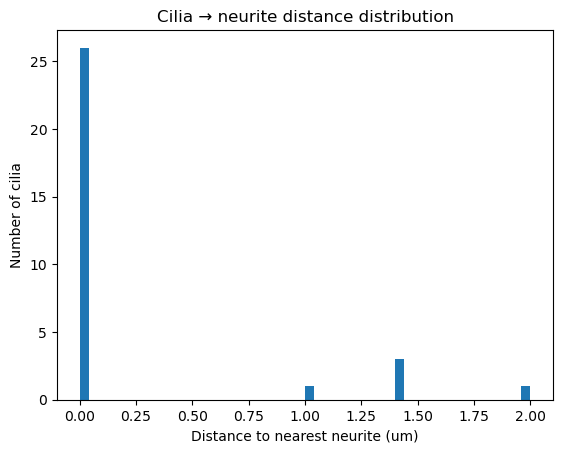

In [42]:
distances = []

for centroid in filtered_centroids:

    z, y, x = np.round(centroid).astype(int)
    d = dist_to_neurite[z, y, x]
    distances.append(d)

plt.hist(distances, bins=50)
plt.xlabel("Distance to nearest neurite (um)")
plt.ylabel("Number of cilia")
plt.title("Cilia → neurite distance distribution")
plt.show()

In [29]:
viewer.add_image(cilia_prob_map)

<Image layer 'cilia_prob_map' at 0x22c2a7c9c90>

In [44]:
import numpy as np
from scipy.ndimage import center_of_mass

vectors = []

for cid, centroid in zip(filtered_cilia_ids, filtered_centroids):

    z, y, x = np.round(centroid).astype(int)

    z = np.clip(z, 0, cilia_labels.shape[0]-1)
    y = np.clip(y, 0, cilia_labels.shape[1]-1)
    x = np.clip(x, 0, cilia_labels.shape[2]-1)

    # nearest neurite voxel
    nz, ny, nx = nearest_idx[:, z, y, x]

    start = np.array([z, y, x])
    end = np.array([nz, ny, nx])

    direction = end - start

    vectors.append([start, direction])

vectors = np.array(vectors)

In [45]:
viewer.add_vectors(
    vectors,
    name="cilia_to_neurite_vectors",
    edge_width=2,
    length=1,
)

<Vectors layer 'cilia_to_neurite_vectors [1]' at 0x22c4e774250>

In [53]:
import numpy as np

scores = np.array(list(cilia_scores.values()))
scores = scores[filtered_cilia_ids]
axon = np.sum(scores > 0.6)
soma = np.sum(scores < 0.2)
ambiguous = np.sum((scores >= 0.2) & (scores <= 0.6))

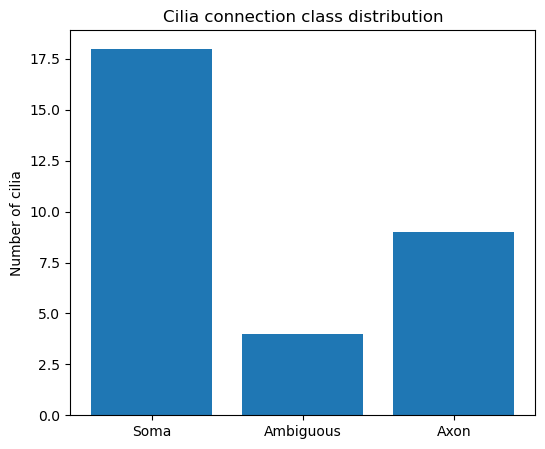

In [54]:
import matplotlib.pyplot as plt

labels = ["Soma", "Ambiguous", "Axon"]
counts = [soma, ambiguous, axon]

plt.figure(figsize=(6,5))
plt.bar(labels, counts)
plt.ylabel("Number of cilia")
plt.title("Cilia connection class distribution")
plt.show()

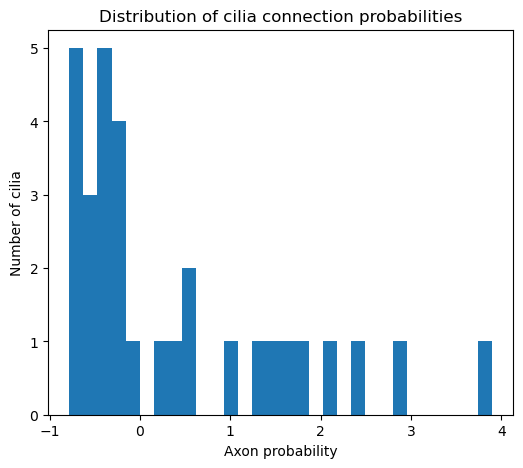

In [55]:
plt.figure(figsize=(6,5))

plt.hist(scores, bins=30)
plt.xlabel("Axon probability")
plt.ylabel("Number of cilia")
plt.title("Distribution of cilia connection probabilities")

plt.show()

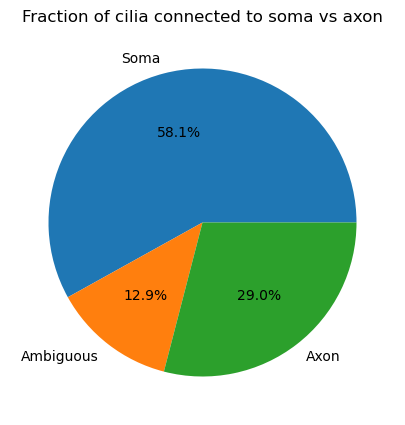

In [56]:
plt.figure(figsize=(6,5))

plt.pie(
    counts,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Fraction of cilia connected to soma vs axon")
plt.show()

In [58]:
filtered_points = np.array(filtered_centroids)

viewer.add_points(
    filtered_points,
    name="filtered_cilia",
    size=6,
    face_color="cyan",
    
)

<Points layer 'filtered_cilia' at 0x22c41116740>